# Few-Shot Sweep Analysis — Qwen2.5-VL-7B

**Run:** `eval_val_100_20260611_151227` &nbsp;|&nbsp; **Split:** val_100 &nbsp;|&nbsp; **Datasets:** SlideVQA, BDocs  
**Conditions:** k=2 random (baseline) · k=2,4,6 specific (corruption-type + complexity matched)  
**Evaluated on:** corrupted questions only — metric is QUR (Question Unanswerability Rate)

---
**Plot 1** — QUR vs k: specific sweep vs random baseline  
**Plot 2** — QUR by corruption complexity (C1/C2/C3) vs k  
**Plot 3** — QUR by NLP entity type: all conditions  
**Plot 4** — Summary heatmap: all conditions × datasets

In [1]:
import os
import re
import json
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

RUN_DIR    = "/home/amartinelli/VRD-UQA/artifacts/evaluation_runs/eval_val_100_20260611_151227"
OUTPUT_DIR = "output_fewshot"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASETS       = ["SlideVQA", "BDocs"]
DATASET_LABELS = {"SlideVQA": "SlideVQA", "BDocs": "BoundingDocs"}

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.linestyle": "--", "grid.alpha": 0.5,
})

## Discover conditions

In [2]:
def parse_slug(slug):
    """Extract (k, selection) from a slug like fewshot_ocr_k4_mixed_specific."""
    m = re.match(r'fewshot_ocr_k(\d+)_mixed_(random|specific)', slug)
    if m:
        return int(m.group(1)), m.group(2)
    return None, None

def discover_configs(dataset):
    out = {}
    for p in sorted(glob.glob(os.path.join(RUN_DIR, dataset, "*", "manifest.json"))):
        with open(p) as f:
            man = json.load(f)
        slug = man["config"]
        k, sel = parse_slug(slug)
        if k is not None:
            out[slug] = {"k": k, "selection": sel, "label": man.get("label", slug)}
    return out

all_configs = {}
for ds in DATASETS:
    all_configs.update(discover_configs(ds))

# Stable order: random first, then specific sorted by k
CONFIGS = sorted(
    all_configs.keys(),
    key=lambda s: (all_configs[s]["selection"] == "specific", all_configs[s]["k"])
)

print("Conditions:")
for c in CONFIGS:
    info = all_configs[c]
    print(f"  {c}  →  k={info['k']}, sel={info['selection']}, label={info['label']}")

Conditions:
  fewshot_ocr_k2_mixed_random  →  k=2, sel=random, label=Few-Shot · OCR · k2-random
  fewshot_ocr_k2_mixed_specific  →  k=2, sel=specific, label=Few-Shot · OCR · k2-specific
  fewshot_ocr_k4_mixed_specific  →  k=4, sel=specific, label=Few-Shot · OCR · k4-specific
  fewshot_ocr_k6_mixed_specific  →  k=6, sel=specific, label=Few-Shot · OCR · k6-specific


## Load metrics

In [3]:
def load_csv(dataset, config, filename):
    path = os.path.join(RUN_DIR, dataset, config, "metrics", filename)
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path, index_col=0)
    df.columns = ["value"]
    return df["value"]

# ── QUR (overall + per complexity) ──────────────────────────────────────────
records = []
for ds in DATASETS:
    for slug in CONFIGS:
        s = load_csv(ds, slug, "QUR.csv")
        if s is None:
            continue
        info = all_configs[slug]
        c3 = s.get("QUR_C3", np.nan)
        if c3 == 0.0:   # 0.0 means no C3 questions exist in this split
            c3 = np.nan
        records.append({
            "dataset":   ds,
            "config":    slug,
            "k":         info["k"],
            "selection": info["selection"],
            "label":     info["label"],
            "QUR":    s.get("QUR",    np.nan),
            "QUR_C1": s.get("QUR_C1", np.nan),
            "QUR_C2": s.get("QUR_C2", np.nan),
            "QUR_C3": c3,
        })

qur_df = pd.DataFrame(records)
qur_df

,dataset,config,k,selection,label,QUR,QUR_C1,QUR_C2,QUR_C3
0,SlideVQA,fewshot_ocr_k2_mixed_random,2,random,Few-Shot · OCR · k2-random,0.52,0.479452,0.666667,0.5
1,SlideVQA,fewshot_ocr_k2_mixed_specific,2,specific,Few-Shot · OCR · k2-specific,0.52,0.465753,0.714286,0.5
2,SlideVQA,fewshot_ocr_k4_mixed_specific,4,specific,Few-Shot · OCR · k4-specific,0.53,0.479452,0.714286,0.5
3,SlideVQA,fewshot_ocr_k6_mixed_specific,6,specific,Few-Shot · OCR · k6-specific,0.54,0.479452,0.761905,0.5
4,BDocs,fewshot_ocr_k2_mixed_random,2,random,Few-Shot · OCR · k2-random,0.66,0.666667,0.636364,NaN
5,BDocs,fewshot_ocr_k2_mixed_specific,2,specific,Few-Shot · OCR · k2-specific,0.63,0.602564,0.727273,NaN
6,BDocs,fewshot_ocr_k4_mixed_specific,4,specific,Few-Shot · OCR · k4-specific,0.62,0.564103,0.818182,NaN
7,BDocs,fewshot_ocr_k6_mixed_specific,6,specific,Few-Shot · OCR · k6-specific,0.68,0.641026,0.818182,NaN


## Plot 1 — QUR vs k: specific sweep vs random baseline

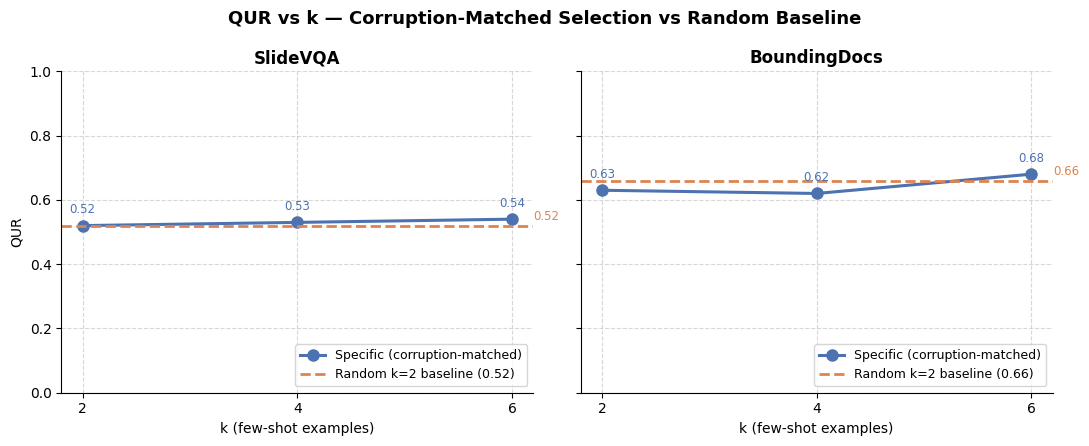

In [4]:
K_SPECIFIC     = [2, 4, 6]
COLOR_SPECIFIC = "#4C72B0"
COLOR_RANDOM   = "#DD8452"

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for idx, ds in enumerate(DATASETS):
    ax   = axes[idx]
    sub  = qur_df[qur_df.dataset == ds]
    spec = sub[sub.selection == "specific"].sort_values("k")
    rand = sub[sub.selection == "random"]

    # Specific sweep line
    ax.plot(
        spec["k"], spec["QUR"],
        marker="o", color=COLOR_SPECIFIC, linewidth=2.2, markersize=8,
        label="Specific (corruption-matched)"
    )
    for _, row in spec.iterrows():
        ax.annotate(
            f"{row['QUR']:.2f}", (row["k"], row["QUR"]),
            textcoords="offset points", xytext=(0, 9),
            ha="center", fontsize=8.5, color=COLOR_SPECIFIC
        )

    # Random baseline — horizontal dashed line across the k range
    if not rand.empty:
        rand_val = rand["QUR"].values[0]
        ax.axhline(
            rand_val, color=COLOR_RANDOM, linestyle="--", linewidth=2,
            label=f"Random k=2 baseline ({rand_val:.2f})"
        )
        ax.annotate(
            f"{rand_val:.2f}",
            (K_SPECIFIC[-1] + 0.15, rand_val),
            textcoords="offset points", xytext=(4, 4),
            ha="left", fontsize=8.5, color=COLOR_RANDOM
        )

    ax.set_xticks(K_SPECIFIC)
    ax.set_xlabel("k (few-shot examples)", fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.set_title(DATASET_LABELS[ds], fontsize=12, fontweight="bold")
    if idx == 0:
        ax.set_ylabel("QUR", fontsize=10)
    ax.legend(fontsize=9, loc="lower right")

fig.suptitle(
    "QUR vs k — Corruption-Matched Selection vs Random Baseline",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot1_qur_vs_k.pdf"), bbox_inches="tight")
plt.show()

## Plot 2 — QUR by corruption complexity vs k

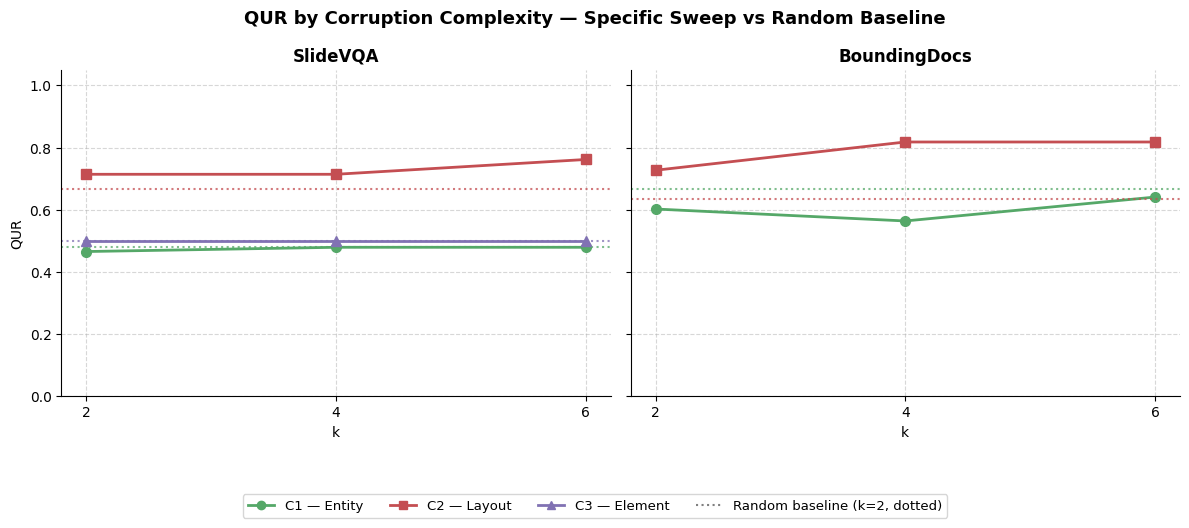

In [5]:
CX_COLS   = ["QUR_C1", "QUR_C2", "QUR_C3"]
CX_LABELS = {"QUR_C1": "C1 — Entity", "QUR_C2": "C2 — Layout", "QUR_C3": "C3 — Element"}
CX_COLORS = {"QUR_C1": "#55A868", "QUR_C2": "#C44E52", "QUR_C3": "#8172B3"}
CX_MARKERS = {"QUR_C1": "o", "QUR_C2": "s", "QUR_C3": "^"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for idx, ds in enumerate(DATASETS):
    ax   = axes[idx]
    sub  = qur_df[qur_df.dataset == ds]
    spec = sub[sub.selection == "specific"].sort_values("k")
    rand = sub[sub.selection == "random"]

    for cx_col in CX_COLS:
        color  = CX_COLORS[cx_col]
        marker = CX_MARKERS[cx_col]
        label  = CX_LABELS[cx_col]

        vals = spec[cx_col].values
        ks   = spec["k"].values
        # Filter NaN so matplotlib doesn't break the line
        mask = ~np.isnan(vals)
        if mask.any():
            ax.plot(
                ks[mask], vals[mask],
                marker=marker, color=color, linewidth=2, markersize=7, label=label
            )

        # Random baseline — dotted horizontal at same colour
        if not rand.empty:
            r_val = rand[cx_col].values[0]
            if not np.isnan(r_val):
                ax.axhline(r_val, color=color, linestyle=":", linewidth=1.5, alpha=0.75)

    ax.set_xticks(K_SPECIFIC)
    ax.set_xlabel("k", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_title(DATASET_LABELS[ds], fontsize=12, fontweight="bold")
    if idx == 0:
        ax.set_ylabel("QUR", fontsize=10)

line_handles = [
    Line2D([0],[0], color=CX_COLORS[c], marker=CX_MARKERS[c], linewidth=2, label=CX_LABELS[c])
    for c in CX_COLS
]
dot_handle = Line2D([0],[0], color="grey", linestyle=":", linewidth=1.5, label="Random baseline (k=2, dotted)")
fig.legend(
    handles=line_handles + [dot_handle],
    loc="lower center", ncol=4, fontsize=9.5, bbox_to_anchor=(0.5, -0.05)
)
fig.suptitle(
    "QUR by Corruption Complexity — Specific Sweep vs Random Baseline",
    fontsize=13, fontweight="bold"
)
plt.tight_layout(rect=[0, 0.09, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "plot2_qur_complexity_vs_k.pdf"), bbox_inches="tight")
plt.show()

## Plot 3 — QUR by NLP entity type: all conditions

In [6]:
ENTITY_TYPES = ["NUMERIC", "TEMPORAL", "ENTITY", "LOCATION", "STRUCTURE"]

nlpe_records = []
for ds in DATASETS:
    for slug in CONFIGS:
        s = load_csv(ds, slug, "QUR_NLPE.csv")
        if s is None:
            continue
        info = all_configs[slug]
        for et in ENTITY_TYPES:
            nlpe_records.append({
                "dataset":   ds,
                "config":    slug,
                "k":         info["k"],
                "selection": info["selection"],
                "label":     info["label"],
                "entity":    et,
                "QUR":       s.get(et, np.nan),
            })

nlpe_df = pd.DataFrame(nlpe_records)
nlpe_df.pivot_table(index=["dataset", "config"], columns="entity", values="QUR")

entity                                    ENTITY  LOCATION   NUMERIC  \
dataset  config                                                        
BDocs    fewshot_ocr_k2_mixed_random    0.468750  0.666667  0.800000   
         fewshot_ocr_k2_mixed_specific  0.531250  0.666667  0.800000   
         fewshot_ocr_k4_mixed_specific  0.562500  0.629630  0.800000   
         fewshot_ocr_k6_mixed_specific  0.562500  0.666667  0.850000   
SlideVQA fewshot_ocr_k2_mixed_random    0.574074  0.439024  0.692308   
         fewshot_ocr_k2_mixed_specific  0.555556  0.487805  0.692308   
         fewshot_ocr_k4_mixed_specific  0.574074  0.487805  0.692308   
         fewshot_ocr_k6_mixed_specific  0.574074  0.560976  0.653846   

entity                                  STRUCTURE  TEMPORAL  
dataset  config                                              
BDocs    fewshot_ocr_k2_mixed_random     0.655172  0.857143  
         fewshot_ocr_k2_mixed_specific   0.551724  0.857143  
         fewshot_ocr_k4_mixed_specific   0.586207  0.857143  
         fewshot_ocr_k6_mixed_specific   0.724138  0.857143  
SlideVQA fewshot_ocr_k2_mixed_random     0.500000  0.400000  
         fewshot_ocr_k2_mixed_specific   0.500000  0.400000  
         fewshot_ocr_k4_mixed_specific   0.500000  0.400000  
         fewshot_ocr_k6_mixed_specific   0.500000  0.400000

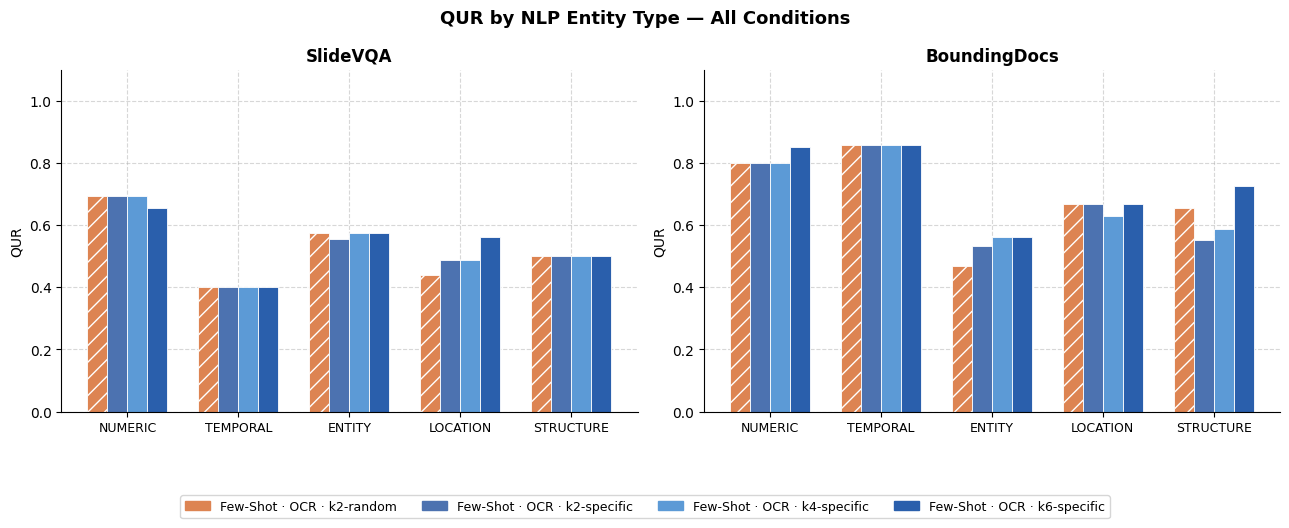

In [7]:
# Color palette — one colour per config, same order as CONFIGS
_PALETTE = ["#DD8452", "#4C72B0", "#5C9AD6", "#2A5FAC"]
CFG_COLORS = {c: _PALETTE[i % len(_PALETTE)] for i, c in enumerate(CONFIGS)}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bar_w = 0.18
x     = np.arange(len(ENTITY_TYPES))

for idx, ds in enumerate(DATASETS):
    ax = axes[idx]
    for i, slug in enumerate(CONFIGS):
        info = all_configs[slug]
        sub  = nlpe_df[(nlpe_df.dataset == ds) & (nlpe_df.config == slug)].set_index("entity")
        if sub.empty:
            continue
        vals = [sub.loc[et, "QUR"] if et in sub.index else np.nan for et in ENTITY_TYPES]

        # Random baseline gets a dashed outline
        hatch = "//" if info["selection"] == "random" else None
        bars  = ax.bar(
            x + i * bar_w, vals, width=bar_w,
            color=CFG_COLORS[slug], label=info["label"],
            edgecolor="white", linewidth=0.6, hatch=hatch
        )

    offset = (len(CONFIGS) - 1) * bar_w / 2
    ax.set_xticks(x + offset)
    ax.set_xticklabels(ENTITY_TYPES, fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("QUR", fontsize=10)
    ax.set_title(DATASET_LABELS[ds], fontsize=12, fontweight="bold")

handles = [
    mpatches.Patch(
        color=CFG_COLORS[c],
        label=all_configs[c]["label"],
        hatch="//" if all_configs[c]["selection"] == "random" else None
    )
    for c in CONFIGS
]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("QUR by NLP Entity Type — All Conditions", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "plot3_qur_nlpe.pdf"), bbox_inches="tight")
plt.show()

## Plot 4 — Summary heatmap: QUR across all conditions × datasets

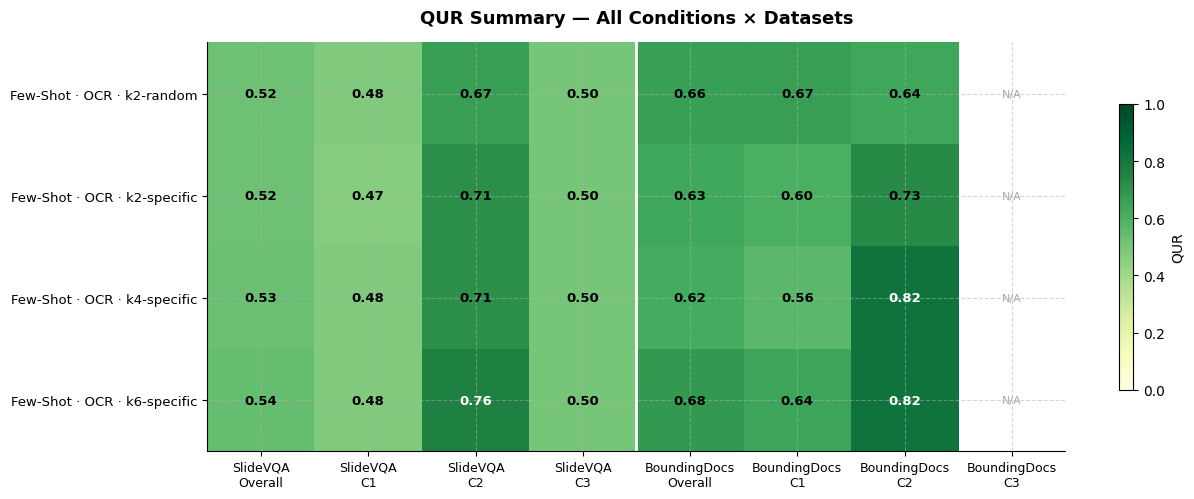

In [8]:
# Rows = conditions, columns = dataset × complexity slot
SLOTS = [
    ("Overall", "QUR"),
    ("C1",      "QUR_C1"),
    ("C2",      "QUR_C2"),
    ("C3",      "QUR_C3"),
]

col_labels = [f"{DATASET_LABELS[ds]}\n{slot_label}" for ds in DATASETS for slot_label, _ in SLOTS]
row_labels = [all_configs[c]["label"] for c in CONFIGS]

heat = np.full((len(CONFIGS), len(col_labels)), np.nan)

for r, slug in enumerate(CONFIGS):
    col_idx = 0
    for ds in DATASETS:
        sub = qur_df[(qur_df.dataset == ds) & (qur_df.config == slug)]
        for _, slot_col in SLOTS:
            if not sub.empty:
                heat[r, col_idx] = sub[slot_col].values[0]
            col_idx += 1

fig, ax = plt.subplots(figsize=(len(col_labels) * 1.5 + 1, len(CONFIGS) * 0.9 + 1.5))
im = ax.imshow(heat, cmap="YlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9.5)

# Draw vertical separators between datasets
n_slots = len(SLOTS)
for sep in range(1, len(DATASETS)):
    ax.axvline(sep * n_slots - 0.5, color="white", linewidth=2)

for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        v = heat[r, c]
        if np.isnan(v):
            ax.text(c, r, "N/A", ha="center", va="center", fontsize=8, color="#aaaaaa")
        else:
            text_color = "white" if v > 0.75 else "black"
            ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                    fontsize=9.5, fontweight="bold", color=text_color)

plt.colorbar(im, ax=ax, label="QUR", shrink=0.7)
ax.set_title(
    "QUR Summary — All Conditions × Datasets",
    fontsize=13, fontweight="bold", pad=14
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot4_summary_heatmap.pdf"), bbox_inches="tight")
plt.show()